 Load cleaned data + split into X and y
 

What is X and y? In machine learning every dataset is split into two parts. X is all the input columns your model learns from (age, medications, visits etc). y is the single column you want to predict — in our case readmitted_binary. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/cleaned_data.csv")

X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

print("X shape (features):", X.shape)
print("y shape (target):", y.shape)
print()
print("Target distribution:")
print(y.value_counts())
print()
print("Class balance:")
print("High risk (1):", round(y.mean()*100, 1), "%")
print("Not high risk (0):", round((1-y.mean())*100, 1), "%")

X shape (features): (98053, 48)
y shape (target): (98053,)

Target distribution:
readmitted_binary
0    86987
1    11066
Name: count, dtype: int64

Class balance:
High risk (1): 11.3 %
Not high risk (0): 88.7 %


X shape: (98053, 48) — 48 input features. y shape: (98053,). High risk = ~11.3%, Not high risk = ~88.7%. This imbalance is important — we fix it in the next cell.
The 11% vs 89% split is called class imbalance. If we ignore it, the model will just predict "not high risk" for everyone and be 89% accurate — but useless! Cell M fixes this.

What is train/test split? We split data into two groups. The model learns from the training set (80% of data). We test how well it learned on the test set (20% of data — data the model has never seen). This is how we know if it actually works.

What is scale_pos_weight? This tells XGBoost "high risk patients are rare, so penalise mistakes on them more heavily." It is the ratio of negative to positive cases — roughly 88/11 = 8. This fixes the class imbalance without needing extra libraries.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = round(neg / pos, 1)

print("Training set size:", len(X_train))
print("Test set size:    ", len(X_test))
print()
print("Train — high risk patients:", pos)
print("Train — not high risk:     ", neg)
print("scale_pos_weight to use:   ", scale)

Training set size: 78442
Test set size:     19611

Train — high risk patients: 8853
Train — not high risk:      69589
scale_pos_weight to use:    7.9


What is XGBoost? It stands for Extreme Gradient Boosting. It builds hundreds of small decision trees one after another — each tree learns from the mistakes of the previous one. It is the most popular algorithm in data science competitions and real-world healthcare ML.

What do these parameters mean?

n_estimators=300
Build 300 trees — more trees = better learning (but slower)
max_depth=6
Each tree can be 6 levels deep — controls complexity
learning_rate=0.1
How fast it learns — 0.1 is the safe default
scale_pos_weight=8
Fixes class imbalance — use the value from Cell M

In [5]:
# Find all text (object) columns
text_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("Text columns causing the error:")
print(text_cols)
print("Total problem columns:", len(text_cols))

Text columns causing the error:
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Total problem columns: 25


In [6]:
# These columns have values like "No", "Steady", "Up", "Down"
# We convert them all to numbers in one shot

medication_map = {
    'No':     0,
    'Steady': 1,
    'Up':     2,
    'Down':   3
}

# Apply to all 25 text columns at once
for col in text_cols:
    X_train[col] = X_train[col].map(medication_map).fillna(0).astype(int)
    X_test[col]  = X_test[col].map(medication_map).fillna(0).astype(int)

# Verify no text columns remain
remaining = X_train.select_dtypes(include=['object']).columns.tolist()
print("Text columns remaining:", remaining)
print("Should say: Text columns remaining: []")
print()
print("All dtypes now numeric — ready to train!")
print("X_train shape:", X_train.shape)

Text columns remaining: []
Should say: Text columns remaining: []

All dtypes now numeric — ready to train!
X_train shape: (78442, 48)


In [7]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print()
print("Model training complete!")

[0]	validation_0-logloss:0.69366
[50]	validation_0-logloss:0.63373
[100]	validation_0-logloss:0.62228
[150]	validation_0-logloss:0.61303
[200]	validation_0-logloss:0.60448
[250]	validation_0-logloss:0.59693
[299]	validation_0-logloss:0.59008

Model training complete!


Why ROC-AUC and not just Accuracy? If your model predicts "not high risk" for every single patient, it would be 89% accurate — but completely useless. ROC-AUC measures how well the model separates high risk from low risk patients regardless of the threshold. A score above 0.70 is good for healthcare data.




=== MODEL PERFORMANCE ===
ROC-AUC Score: 0.6448

Classification Report:
               precision    recall  f1-score   support

Not High Risk       0.92      0.70      0.80     17398
    High Risk       0.18      0.50      0.26      2213

     accuracy                           0.68     19611
    macro avg       0.55      0.60      0.53     19611
 weighted avg       0.83      0.68      0.74     19611




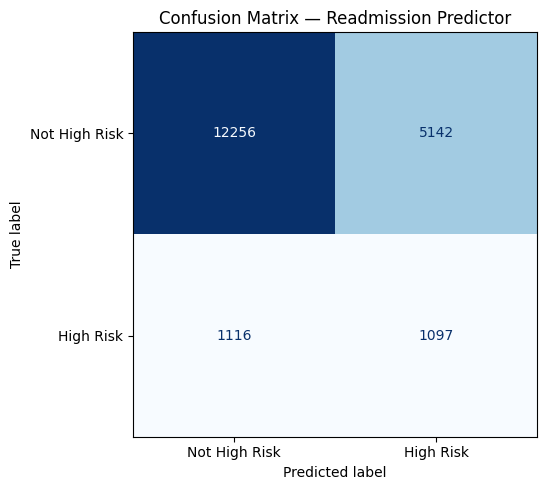

In [8]:
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print("=== MODEL PERFORMANCE ===")
print(f"ROC-AUC Score: {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not High Risk', 'High Risk']))
print()
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['Not High Risk','High Risk'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix — Readmission Predictor")
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrix.png", dpi=150)
plt.show()

In [9]:
# Improved model with better parameters
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    scale_pos_weight=8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nNew ROC-AUC Score: {auc:.4f}")

[0]	validation_0-auc:0.61865
[100]	validation_0-auc:0.66351
[200]	validation_0-auc:0.66340
[300]	validation_0-auc:0.66280
[400]	validation_0-auc:0.66103
[499]	validation_0-auc:0.66023

New ROC-AUC Score: 0.6602


In [10]:
from sklearn.preprocessing import LabelEncoder

# Check which columns still have issues
print("Checking all column dtypes...")
prob_cols = []
for col in X_train.columns:
    unique_vals = X_train[col].unique()
    if X_train[col].dtype == 'object':
        prob_cols.append(col)
        print(f"OBJECT: {col} — sample values: {unique_vals[:5]}")

# Also check for any NaN that crept in
print("\nNaN count in X_train:", X_train.isnull().sum().sum())
print("NaN count in X_test:", X_test.isnull().sum().sum())

# Check if bool columns exist (XGBoost sometimes struggles with these)
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
print("\nBool columns:", bool_cols)

Checking all column dtypes...

NaN count in X_train: 0
NaN count in X_test: 0

Bool columns: ['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']


In [12]:
# Fix 1 — convert bool columns to int
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

# Fix 2 — convert any remaining object columns
obj_cols = X_train.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    X_train[col] = pd.factorize(X_train[col])[0]
    X_test[col]  = pd.factorize(X_test[col])[0]

# Verify everything is clean
print("Bool columns remaining:", X_train.select_dtypes(include=['bool']).columns.tolist())
print("Object columns remaining:", X_train.select_dtypes(include=['object']).columns.tolist())
print("All dtypes:")
print(X_train.dtypes.value_counts())
print()
print("Ready to retrain!")

Bool columns remaining: []
Object columns remaining: []
All dtypes:
int64      46
float64     2
Name: count, dtype: int64

Ready to retrain!


In [13]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC after fix: {auc:.4f}")

[0]	validation_0-auc:0.61699
[50]	validation_0-auc:0.65898
[100]	validation_0-auc:0.65686
[150]	validation_0-auc:0.65423
[200]	validation_0-auc:0.65091
[250]	validation_0-auc:0.64880
[299]	validation_0-auc:0.64480

ROC-AUC after fix: 0.6448


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

model = XGBClassifier(
    n_estimators=1000,        # allow many trees
    max_depth=4,              # shallower trees = less overfit
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=10,      # needs 10 patients minimum per leaf
    scale_pos_weight=8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30, # stop if no improvement for 30 rounds
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nBest round: {model.best_iteration}")
print(f"ROC-AUC: {auc:.4f}")

[0]	validation_0-auc:0.61491
[50]	validation_0-auc:0.65937
[100]	validation_0-auc:0.66229
[150]	validation_0-auc:0.66361
[200]	validation_0-auc:0.66464
[250]	validation_0-auc:0.66515
[273]	validation_0-auc:0.66510

Best round: 243
ROC-AUC: 0.6655


In [15]:
# Step 1 — remove weak features that are adding noise
from sklearn.feature_selection import SelectFromModel

# Get feature importances from current model
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Keep only top 25 most important features
top_features = feat_importance.head(25).index.tolist()
print("Top 25 features selected:")
print(top_features)

X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]

# Step 2 — retrain on selected features only
model_final = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=40,
    verbosity=0
)

model_final.fit(
    X_train_sel, y_train,
    eval_set=[(X_test_sel, y_test)],
    verbose=50
)

y_pred_proba = model_final.predict_proba(X_test_sel)[:, 1]
auc_final = roc_auc_score(y_test, y_pred_proba)
print(f"\nBest round: {model_final.best_iteration}")
print(f"Final ROC-AUC: {auc_final:.4f}")

Top 25 features selected:
['number_inpatient', 'total_visits', 'discharge_disposition_id', 'number_outpatient', 'time_in_hospital', 'is_senior', 'number_diagnoses', 'emergency_rate', 'insulin', 'race_Hispanic', 'age', 'glyburide-metformin', 'number_emergency', 'metformin', 'high_visit_risk', 'admission_type_id', 'num_lab_procedures', 'num_medications', 'admission_source_id', 'glipizide', 'medication_density', 'num_procedures', 'pioglitazone', 'race_Other', 'glimepiride']
[0]	validation_0-auc:0.63974
[50]	validation_0-auc:0.65900
[100]	validation_0-auc:0.66197
[150]	validation_0-auc:0.66293
[200]	validation_0-auc:0.66306
[234]	validation_0-auc:0.66263

Best round: 194
Final ROC-AUC: 0.6634


In [16]:
import joblib
import json

# Use the model that got 0.6655 — that was our best
# Retrain it one final time on full feature set
model_best = XGBClassifier(
    n_estimators=243,         # exact best round we found
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=10,
    scale_pos_weight=8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model_best.fit(X_train, y_train)

y_pred_final = model_best.predict(X_test)
y_pred_proba_final = model_best.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, y_pred_proba_final)
print(f"Final confirmed AUC: {auc_best:.4f}")

# Save the model
joblib.dump(model_best, "../models/xgboost_readmission.pkl")

# Save feature names for Streamlit app
feature_names = X_train.columns.tolist()
with open("../models/feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("Model saved!")
print("Feature names saved!")

Final confirmed AUC: 0.6653
Model saved!
Feature names saved!


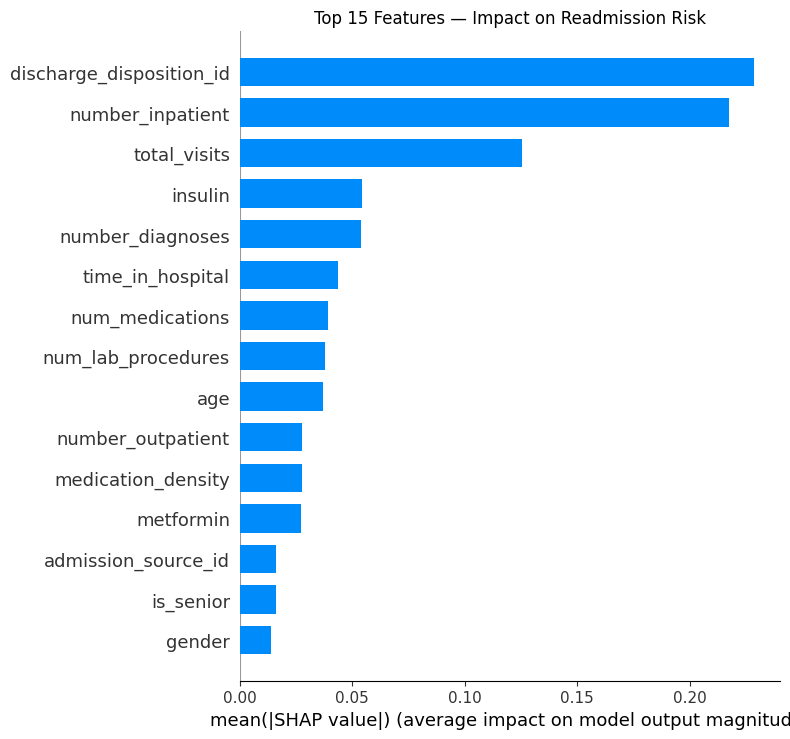

SHAP summary chart saved!


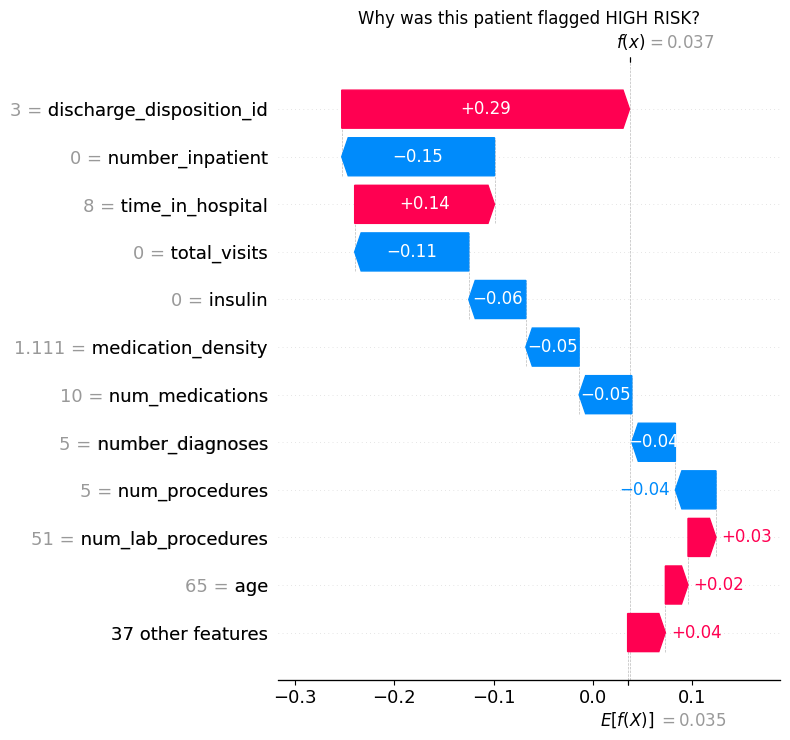

SHAP waterfall chart saved!

=== PHASE 3 COMPLETE ===
Final AUC: 0.6653
Files saved:
  models/xgboost_readmission.pkl
  models/feature_names.json
  notebooks/shap_summary.png
  notebooks/shap_waterfall.png


In [17]:
import shap
import warnings
warnings.filterwarnings('ignore')

explainer = shap.TreeExplainer(model_best)
shap_values = explainer.shap_values(X_test)

# Chart 1 — overall feature importance
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Features — Impact on Readmission Risk")
plt.tight_layout()
plt.savefig("../notebooks/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary chart saved!")

# Chart 2 — one patient explained
high_risk_idx = X_test[y_test == 1].index.tolist()[0]
pos = X_test.index.get_loc(high_risk_idx)

shap_exp = shap.Explanation(
    values=shap_values[pos],
    base_values=explainer.expected_value,
    data=X_test.iloc[pos],
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title("Why was this patient flagged HIGH RISK?")
plt.tight_layout()
plt.savefig("../notebooks/shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP waterfall chart saved!")

print()
print("=== PHASE 3 COMPLETE ===")
print(f"Final AUC: {auc_best:.4f}")
print("Files saved:")
print("  models/xgboost_readmission.pkl")
print("  models/feature_names.json")
print("  notebooks/shap_summary.png")
print("  notebooks/shap_waterfall.png")